In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import h, c, k
from scipy.interpolate import interp1d

# 读取 tau(λ) 数据，确保文件名正确
tau_df = pd.read_csv('tau_lambda.csv')
tau_df.columns = ['wavelength_um', 'tau']
tau_df = tau_df.sort_values(by='wavelength_um')
tau_df['wavelength_m'] = tau_df['wavelength_um'] * 1e-6

# 限定波长范围为 8–13 μm
lambda_vals_restricted = tau_df[
    (tau_df['wavelength_um'] >= 8) & (tau_df['wavelength_um'] <= 13)
]
lambda_vals_m = lambda_vals_restricted['wavelength_m'].values
tau_vals = lambda_vals_restricted['tau'].values
d_lambda = np.gradient(lambda_vals_m)

# 定义黑体辐射函数
def I_BB(T, wavelength):
    return (2 * h * c**2) / (wavelength**5) / (np.exp(h * c / (wavelength * k * T)) - 1)

# 离散角度
theta_vals = np.linspace(0, np.pi/2, 90)
cos_theta = np.cos(theta_vals)
sin_theta = np.sin(theta_vals)
d_theta = np.gradient(theta_vals)

# 根据给定公式计算 P_cool(T)
def P_cool(T):
    I_vals = I_BB(T, lambda_vals_m)
    total_power = 0
    for i, theta in enumerate(theta_vals):
        cos_t = cos_theta[i]
        sin_t = sin_theta[i]
        tau_theta = tau_vals ** (1 / cos_t)
        integrand_lambda = I_vals * tau_theta
        lambda_integrated = np.sum(integrand_lambda * d_lambda)
        total_power += lambda_integrated * cos_t * sin_t * d_theta[i]
    return 2 * np.pi * total_power

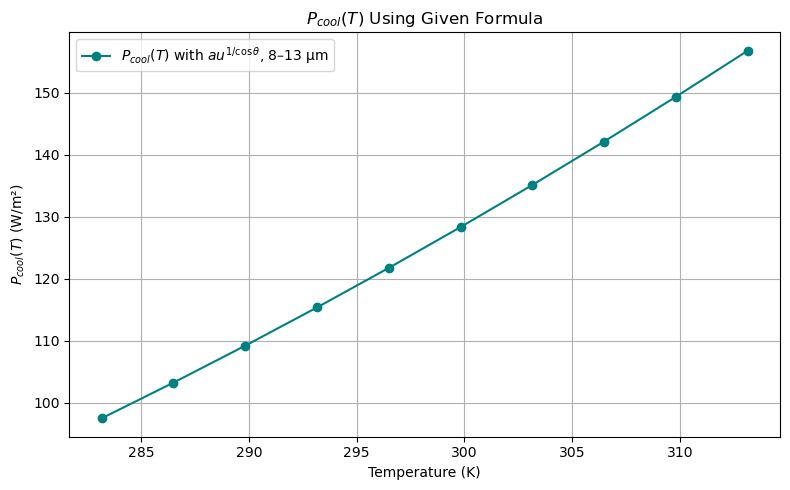

In [13]:
# 计算温度范围内的 P_cool
temperatures = np.linspace(10+273.15, 40+273.15, 10)  
Pcool_values = [P_cool(T) for T in temperatures]

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(temperatures, Pcool_values, marker='o', color='teal',
         label=r'$P_{cool}(T)$ with $	au^{1/\cos\theta}$, 8–13 μm')
plt.title(r'$P_{cool}(T)$ Using Given Formula')
plt.xlabel('Temperature (K)')
plt.ylabel(r'$P_{cool}(T)$ (W/m²)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# 计算温度范围内的 P_cool，步长为 1 K, 范围为 250–350 K, 存入df中
temperatures_full = np.arange(250, 351, 1)  # 温度范围
Pcool_values_full = [P_cool(T) for T in temperatures_full]
Pcool_df = pd.DataFrame({
    'Temperature (K)': temperatures_full,
    'P_cool (W/m²)': Pcool_values_full
})

In [ ]:
Pcool_df.to_csv('Pcool_values.txt', sep= "\t", index=False)  # 保存为 CSV 文件

,Temperature (K),P_cool (W/m²)
35,285,100.630133


In [12]:
# 10°C 时的 P_cool 值
float(P_cool(10+273.15))
print("P_cool(10°C):", P_cool(10+273.15))
# 40°C 时的 P_cool 值
print("P_cool(40°C):", P_cool(40+273.15))

P_cool(10°C): 97.457219598458
P_cool(40°C): 156.82616189657497
